# Verification Data Analysis

This notebook:
- loads `verification_full_results.csv`
- builds paper-aligned error-type labels from the 9 strategy codes
- analyzes verification error types at aggregate and per-student levels
- computes and visualizes a full student-student correlation heatmap


In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

In [32]:
cwd = Path.cwd()
if (cwd / 'UMA_replication').exists():
    results_dir = cwd
elif (cwd / 'results' / 'UMA_replication').exists():
    results_dir = cwd / 'results'
else:
    raise FileNotFoundError('Could not find UMA_replication folder from current working directory.')

verification_path = results_dir / 'UMA_replication' / 'verification_full_results.csv'
if not verification_path.exists():
    raise FileNotFoundError(f'Could not find: {verification_path}')

print(f'Using verification file: {verification_path}')


Using verification file: /Users/chshin/UMA_PR02/results/UMA_replication/verification_full_results.csv


In [33]:
verification_df = pd.read_csv(verification_path, low_memory=False)

print(f'verification_df shape: {verification_df.shape}')
display(verification_df.head())


verification_df shape: (15936, 27)


,Unnamed: 0,subjid,g,d,c,rt_mu,rt_sd,ice,prob,notation,operation,operands,denoms,key,steps,time,acc,ans,KDON_AS,KDON_OG,CDON_AS,CDON_OG,ONOD_M,ONOD_OG,CROP_M,ICDM_D,ICDM_OG
0,0,811,0.09,0.1,5,5,1,25,3/5+1/5,fraction,add,FR,ED,0.800000,19,0.094849,0,2/5,0,0,0,0,0,1,0,0,0
1,1,811,0.09,0.1,5,5,1,25,4/5+3/5,fraction,add,FR,ED,1.400000,12,0.049281,1,7/5,0,1,0,0,0,0,0,0,0
2,2,811,0.09,0.1,5,5,1,25,3/5+1/4,fraction,add,FR,UD,0.850000,15,0.071257,0,4/9,0,0,0,0,0,1,0,0,0
3,3,811,0.09,0.1,5,5,1,25,2/3+3/5,fraction,add,FR,UD,1.266667,46,0.188615,1,19/15,0,0,0,1,0,0,0,0,0
4,4,811,0.09,0.1,5,5,1,25,3/5-1/5,fraction,sub,FR,ED,0.400000,11,0.039577,1,2/5,0,1,0,0,0,0,0,0,0


## Helper functions and taxonomy

### Strategy/Error Codebook

The 9 strategy codes follow UMA rule names in `1. Model/models.py`:
- `KDON_AS`, `KDON_OG`, `CDON_AS`, `CDON_OG`
- `ONOD_M`, `ONOD_OG`, `CROP_M`
- `ICDM_D`, `ICDM_OG`

Grouped families used in analysis:
- `AS`: `KDON_*`, `CDON_*`
- `M`: `ONOD_*`, `CROP_M`
- `D`: `ICDM_*`


In [34]:
STRATEGY_CODES = [
    'KDON_AS', 'KDON_OG', 'CDON_AS', 'CDON_OG',
    'ONOD_M', 'ONOD_OG', 'CROP_M', 'ICDM_D', 'ICDM_OG'
]

STRATEGY_TO_FAMILY = {
    'KDON_AS': 'AS', 'KDON_OG': 'AS', 'CDON_AS': 'AS', 'CDON_OG': 'AS',
    'ONOD_M': 'M', 'ONOD_OG': 'M', 'CROP_M': 'M',
    'ICDM_D': 'D', 'ICDM_OG': 'D',
}

OP_TO_APPROPRIATE = {
    'add': {'KDON_AS', 'CDON_AS'},
    'sub': {'KDON_AS', 'CDON_AS'},
    'mul': {'ONOD_M', 'CROP_M'},
    'div': {'ICDM_D'},
}


def normalize_operation(op: str) -> str:
    if pd.isna(op):
        return np.nan
    token = str(op).strip().lower()
    mapping = {
        '+': 'add', '-': 'sub', '*': 'mul', ':': 'div',
        'add': 'add', 'sub': 'sub', 'mul': 'mul', 'div': 'div',
    }
    return mapping.get(token, np.nan)


def derive_error_type_tag(strategy_code: str, operation_norm: str) -> str:
    code = str(strategy_code).strip()
    if code.endswith('_OG'):
        return 'Overgeneralized'
    if code in OP_TO_APPROPRIATE.get(operation_norm, set()):
        return 'Operation-Appropriate'
    return 'Other Inappropriate'


def extract_strategy_code(df: pd.DataFrame, strategy_cols: list[str]) -> pd.Series:
    missing = [c for c in strategy_cols if c not in df.columns]
    assert not missing, f'Missing strategy columns: {missing}'

    one_hot_sums = df[strategy_cols].sum(axis=1)
    assert (one_hot_sums == 1).all(), 'Verification strategy one-hot rows must sum to 1.'
    return df[strategy_cols].idxmax(axis=1)


def annotate_verification_taxonomy(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['operation_norm'] = out['operation'].map(normalize_operation)
    out['strategy_code'] = extract_strategy_code(out, STRATEGY_CODES)
    out['error_flag'] = out['acc'].eq(0)

    out['strategy_family'] = out['strategy_code'].map(STRATEGY_TO_FAMILY)
    out['is_overgeneralized'] = out['strategy_code'].astype(str).str.endswith('_OG')

    out['is_operation_appropriate'] = out.apply(
        lambda r: r['strategy_code'] in OP_TO_APPROPRIATE.get(r['operation_norm'], set()),
        axis=1,
    )
    out['error_type_tag'] = out.apply(
        lambda r: derive_error_type_tag(r['strategy_code'], r['operation_norm']),
        axis=1,
    )
    return out


def summarize_error_types(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    summary = df.groupby(group_cols, dropna=False).size().rename('count').reset_index()
    total = summary['count'].sum()
    summary['proportion'] = summary['count'] / total if total > 0 else 0.0
    return summary.sort_values('count', ascending=False).reset_index(drop=True)


def mechanism_rates(err_df: pd.DataFrame) -> pd.DataFrame:
    order = ['Overgeneralized', 'Operation-Appropriate', 'Other Inappropriate']
    rates = err_df['error_type_tag'].value_counts(normalize=True).reindex(order, fill_value=0.0)
    return rates.rename_axis('mechanism').reset_index(name='rate')


def build_student_error_profile(df: pd.DataFrame) -> pd.DataFrame:
    profile = (
        df.pivot_table(
            index='subjid',
            columns='prob',
            values='error_flag',
            aggfunc='max',
            fill_value=0,
        )
        .sort_index(axis=0)
        .reindex(sorted(df['prob'].unique()), axis=1)
        .astype(int)
    )
    return profile


def compute_student_corr(profile_df: pd.DataFrame, method: str = 'pearson') -> pd.DataFrame:
    corr = profile_df.T.corr(method=method).astype(float)

    corr = corr.fillna(0.0)
    corr = (corr + corr.T) / 2.0
    np.fill_diagonal(corr.values, 1.0)

    return corr


## 1) Load and validate

In [35]:
required_verif_cols = {'subjid', 'prob', 'operation', 'acc', 'ans', 'key', *STRATEGY_CODES}
assert required_verif_cols.issubset(verification_df.columns), (
    f'Missing in verification: {required_verif_cols - set(verification_df.columns)}'
)

one_hot_sums = verification_df[STRATEGY_CODES].sum(axis=1)
assert (one_hot_sums == 1).all(), 'Verification strategy one-hot rows must sum to 1.'

print('verification unique subjid:', verification_df['subjid'].nunique())
print('verification unique prob:', verification_df['prob'].nunique())
print('Verification strategy one-hot check passed.')


verification unique subjid: 996
verification unique prob: 16
Verification strategy one-hot check passed.


## 2) Preprocess and harmonize

In [36]:
if 'Unnamed: 0' in verification_df.columns:
    verification_df = verification_df.drop(columns=['Unnamed: 0'])

verification_annot = annotate_verification_taxonomy(verification_df)

assert set(verification_annot['strategy_code'].unique()).issubset(set(STRATEGY_CODES))
assert verification_annot['strategy_family'].notna().all()
assert verification_annot['error_flag'].dtype == bool

print('Preprocess + taxonomy checks passed.')
print('verification operations:', sorted(verification_annot['operation_norm'].dropna().unique()))


Preprocess + taxonomy checks passed.
verification operations: ['add', 'div', 'mul', 'sub']


## 2.5) Tagging examples

`error_type_tag` assignment priority:
1. `strategy_code` ending with `_OG` -> `Overgeneralized`
2. Otherwise, if the strategy matches the operation -> `Operation-Appropriate`
3. Otherwise -> `Other Inappropriate`


In [37]:
toy_examples = pd.DataFrame([
    {'operation': 'add', 'strategy_code': 'KDON_OG', 'note': 'OG suffix always tags as overgeneralized'},
    {'operation': 'add', 'strategy_code': 'KDON_AS', 'note': 'Add/sub strategy on add'},
    {'operation': 'mul', 'strategy_code': 'ICDM_D', 'note': 'Division strategy used on multiply'},
    {'operation': 'div', 'strategy_code': 'ICDM_D', 'note': 'Division strategy on divide'},
    {'operation': 'sub', 'strategy_code': 'ONOD_M', 'note': 'Multiply strategy used on subtraction'},
])

toy_examples['operation_norm'] = toy_examples['operation'].map(normalize_operation)
toy_examples['strategy_family'] = toy_examples['strategy_code'].map(STRATEGY_TO_FAMILY)
toy_examples['is_overgeneralized'] = toy_examples['strategy_code'].str.endswith('_OG')
toy_examples['is_operation_appropriate'] = toy_examples.apply(
    lambda r: r['strategy_code'] in OP_TO_APPROPRIATE.get(r['operation_norm'], set()),
    axis=1,
)
toy_examples['error_type_tag'] = toy_examples.apply(
    lambda r: derive_error_type_tag(r['strategy_code'], r['operation_norm']),
    axis=1,
)

print('Toy examples of strategy tagging:')
display(toy_examples)

sample_cols = ['subjid', 'prob', 'operation', 'strategy_code', 'acc', 'ans', 'key', 'error_type_tag']
sample_verif_rows = (
    verification_annot.loc[verification_annot['error_flag'], sample_cols]
    .groupby('error_type_tag', group_keys=False)
    .head(5)
    .sort_values(['error_type_tag', 'subjid', 'prob'])
)

print('Sample incorrect verification rows from your data by error_type_tag:')
display(sample_verif_rows)


Toy examples of strategy tagging:


,operation,strategy_code,note,operation_norm,strategy_family,is_overgeneralized,is_operation_appropriate,error_type_tag
0,add,KDON_OG,OG suffix always tags as overgeneralized,add,AS,True,False,Overgeneralized
1,add,KDON_AS,Add/sub strategy on add,add,AS,False,True,Operation-Appropriate
2,mul,ICDM_D,Division strategy used on multiply,mul,D,False,False,Other Inappropriate
3,div,ICDM_D,Division strategy on divide,div,D,False,True,Operation-Appropriate
4,sub,ONOD_M,Multiply strategy used on subtraction,sub,M,False,False,Other Inappropriate


Sample incorrect verification rows from your data by error_type_tag:


,subjid,prob,operation,strategy_code,acc,ans,key,error_type_tag
50,203,3/5+1/4,add,CDON_AS,0,1/5,0.850000,Operation-Appropriate
54,203,3/5-1/4,sub,CDON_AS,0,1/10,0.350000,Operation-Appropriate
30,457,3/5:1/4,div,ICDM_D,0,5/12,2.400000,Operation-Appropriate
25,457,4/5*3/5,mul,CROP_M,0,4/3,0.480000,Operation-Appropriate
41,913,4/5*3/5,mul,CROP_M,0,3/4,0.480000,Operation-Appropriate
7,811,2/3-3/5,sub,ONOD_OG,0,1/2,0.066667,Overgeneralized
8,811,3/5*1/5,mul,KDON_OG,0,3/5,0.120000,Overgeneralized
2,811,3/5+1/4,add,ONOD_OG,0,4/9,0.850000,Overgeneralized
0,811,3/5+1/5,add,ONOD_OG,0,2/5,0.800000,Overgeneralized
13,811,4/5:3/5,div,KDON_OG,0,1/5,1.333333,Overgeneralized


## 3) Aggregate error-type analysis (incorrect trials only)

In [38]:
verif_errors = verification_annot[verification_annot['error_flag']].copy()

print('Verification errors:', len(verif_errors))

verif_raw_summary = summarize_error_types(verif_errors, ['strategy_code'])
verif_family_summary = summarize_error_types(verif_errors, ['strategy_family'])
verif_mech = mechanism_rates(verif_errors)

for name, tbl in [
    ('verification raw', verif_raw_summary),
    ('verification family', verif_family_summary),
]:
    s = tbl['proportion'].sum()
    assert np.isclose(s, 1.0), f'Proportions must sum to 1 for {name}; got {s}'

print('Verification raw error-type summary')
display(verif_raw_summary)
print('Verification family summary')
display(verif_family_summary)
print('Verification mechanism rates')
display(verif_mech)


Verification errors: 7480
Verification raw error-type summary


,strategy_code,count,proportion
0,ONOD_OG,2388,0.319251
1,CDON_OG,1516,0.202674
2,ICDM_OG,1451,0.193984
3,KDON_OG,1211,0.161898
4,ICDM_D,313,0.041845
5,CROP_M,303,0.040508
6,CDON_AS,211,0.028209
7,ONOD_M,77,0.010294
8,KDON_AS,10,0.001337


Verification family summary


,strategy_family,count,proportion
0,AS,2948,0.394118
1,M,2768,0.370053
2,D,1764,0.235829


Verification mechanism rates


,mechanism,rate
0,Overgeneralized,0.877807
1,Operation-Appropriate,0.122193
2,Other Inappropriate,0.000000


/var/folders/41/2xrnw50s1cg695ql9qbf9y0h0000gn/T/ipykernel_81563/3013970668.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_counts.index, y=family_counts.values, ax=axes[1], palette='Set2')
/var/folders/41/2xrnw50s1cg695ql9qbf9y0h0000gn/T/ipykernel_81563/3013970668.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=verif_mech, x='mechanism', y='rate', ax=axes[2], palette='viridis')


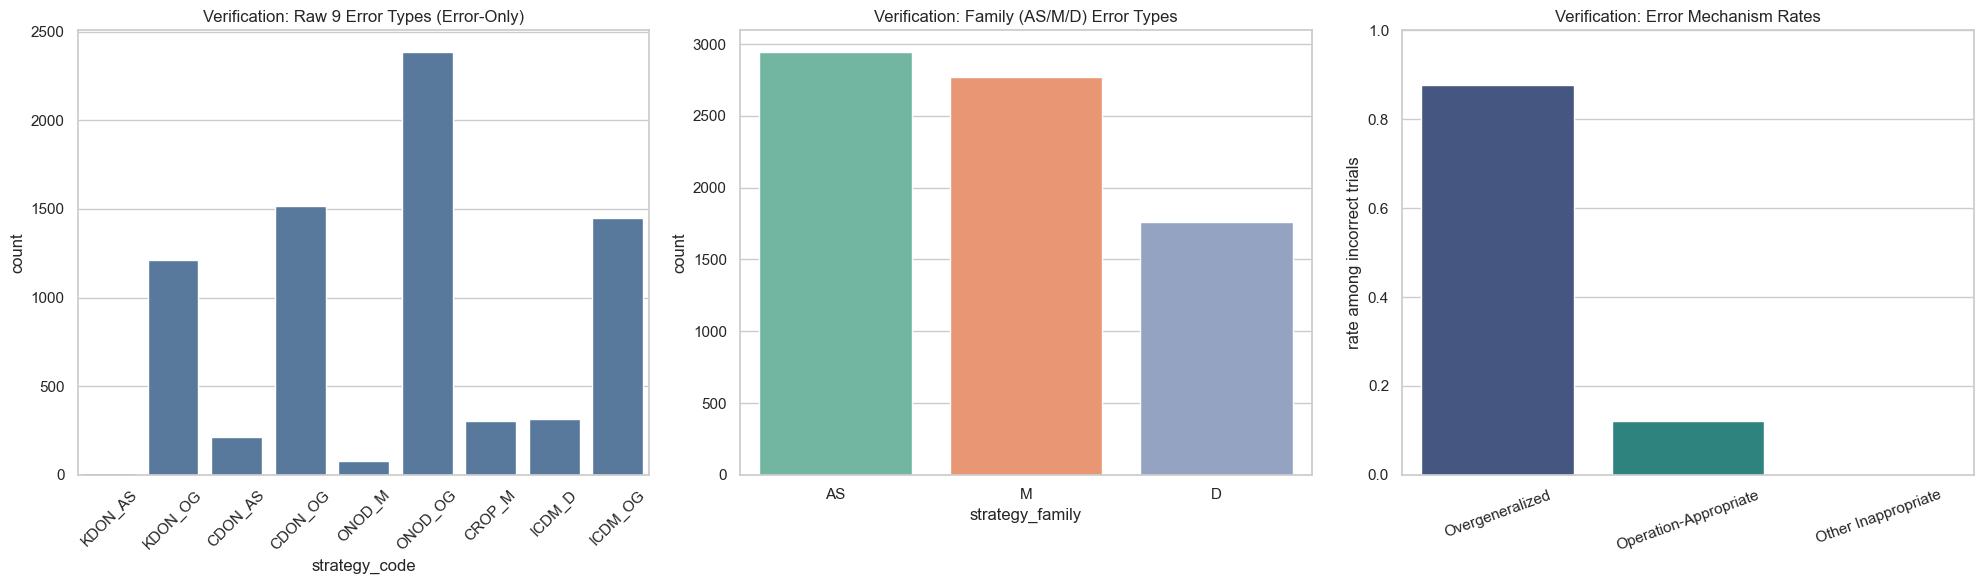

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

raw_counts = verif_errors['strategy_code'].value_counts().reindex(STRATEGY_CODES, fill_value=0)
sns.barplot(x=raw_counts.index, y=raw_counts.values, ax=axes[0], color='#4C78A8')
axes[0].set_title('Verification: Raw 9 Error Types (Error-Only)')
axes[0].set_xlabel('strategy_code')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=45)

family_counts = verif_errors['strategy_family'].value_counts().reindex(['AS', 'M', 'D'], fill_value=0)
sns.barplot(x=family_counts.index, y=family_counts.values, ax=axes[1], palette='Set2')
axes[1].set_title('Verification: Family (AS/M/D) Error Types')
axes[1].set_xlabel('strategy_family')
axes[1].set_ylabel('count')

sns.barplot(data=verif_mech, x='mechanism', y='rate', ax=axes[2], palette='viridis')
axes[2].set_title('Verification: Error Mechanism Rates')
axes[2].set_xlabel('')
axes[2].set_ylabel('rate among incorrect trials')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


/var/folders/41/2xrnw50s1cg695ql9qbf9y0h0000gn/T/ipykernel_81563/2859519765.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=verif_mech, x='mechanism', y='rate', ax=axes[2], palette='viridis')


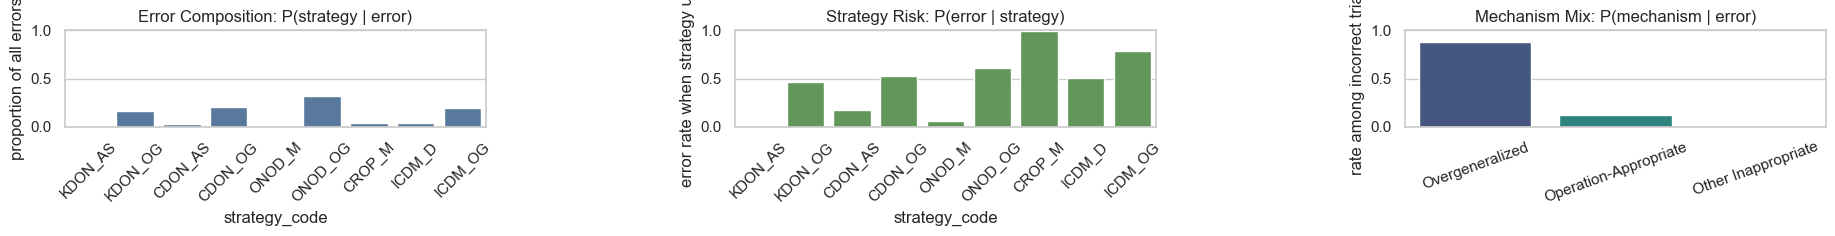

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1) Composition among errors: P(strategy | error)
err_share = (
    verif_errors['strategy_code']
    .value_counts(normalize=True)
    .reindex(STRATEGY_CODES, fill_value=0.0)
)
sns.barplot(x=err_share.index, y=err_share.values, ax=axes[0], color='#4C78A8')
axes[0].set_title('Error Composition: P(strategy | error)')
axes[0].set_xlabel('strategy_code')
axes[0].set_ylabel('proportion of all errors')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)

# 2) Risk by strategy: P(error | strategy)
attempts = verification_annot['strategy_code'].value_counts().reindex(STRATEGY_CODES, fill_value=0)
errors = verif_errors['strategy_code'].value_counts().reindex(STRATEGY_CODES, fill_value=0)
risk = (errors / attempts.replace(0, np.nan)).fillna(0.0)
sns.barplot(x=risk.index, y=risk.values, ax=axes[1], color='#59A14F')
axes[1].set_title('Strategy Risk: P(error | strategy)')
axes[1].set_xlabel('strategy_code')
axes[1].set_ylabel('error rate when strategy used')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1)

# 3) Mechanism rates (already normalized among errors)
sns.barplot(data=verif_mech, x='mechanism', y='rate', ax=axes[2], palette='viridis')
axes[2].set_title('Mechanism Mix: P(mechanism | error)')
axes[2].set_xlabel('')
axes[2].set_ylabel('rate among incorrect trials')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


In [58]:
verif_mech_relabel = verif_mech.copy()
verif_mech_relabel['mechanism'] = verif_mech_relabel['mechanism'].replace(
    
    {   'Overgeneralized': 'Overgeneralization',
        'Operation-Appropriate': 'Omission or misexecution'})
verif_mech_relabel = verif_mech_relabel[verif_mech_relabel['mechanism'] != 'Other Inappropriate']
verif_mech_relabel

,mechanism,rate
0,Overgeneralization,0.877807
1,Omission or misexecution,0.122193


/var/folders/41/2xrnw50s1cg695ql9qbf9y0h0000gn/T/ipykernel_81563/2489924492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=verif_mech_relabel, x='mechanism', y='rate', ax=ax, palette='viridis')


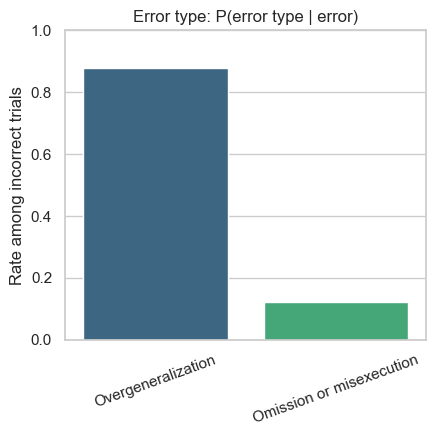

In [62]:
# Mechanism rates (already normalized among errors) — individual plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.barplot(data=verif_mech_relabel, x='mechanism', y='rate', ax=ax, palette='viridis')
ax.set_title('Error type: P(error type | error)')
ax.set_xlabel('')
ax.set_ylabel('Rate among incorrect trials')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
tmp = verification_annot.copy()
tmp['og_err'] = tmp['error_flag'] & tmp['is_overgeneralized']

op_stats = tmp.groupby('operation_norm').agg(
    n_total=('og_err', 'size'),
    n_errors=('error_flag', 'sum'),
    n_og_errors=('og_err', 'sum'),
)
op_stats['og_error_rate_per_attempt'] = op_stats['n_og_errors'] / op_stats['n_total']
op_stats['og_share_within_errors'] = op_stats['n_og_errors'] / op_stats['n_errors']
display(op_stats)


OG error counts by operation x OG type


strategy_code,KDON_OG,CDON_OG,ONOD_OG,ICDM_OG
operation_norm,,,,
add,5,141,839,457
sub,0,107,778,420
mul,414,406,71,255
div,792,862,700,319


Within-operation OG-type share (%)


strategy_code,KDON_OG,CDON_OG,ONOD_OG,ICDM_OG
operation_norm,,,,
add,0.35,9.78,58.18,31.69
sub,0.00,8.20,59.62,32.18
mul,36.13,35.43,6.20,22.25
div,29.63,32.25,26.19,11.93


OG-type error rate per operation attempt (%)


strategy_code,KDON_OG,CDON_OG,ONOD_OG,ICDM_OG
operation_norm,,,,
add,0.13,3.54,21.06,11.47
sub,0.00,2.69,19.53,10.54
mul,10.39,10.19,1.78,6.40
div,19.88,21.64,17.57,8.01


In [65]:
ops = ['add', 'sub', 'mul', 'div']
og_codes = ['KDON_OG', 'CDON_OG', 'ONOD_OG', 'ICDM_OG', 'CROP_M']  # OG-like set


og_err = verification_annot[
    verification_annot['error_flag'] & verification_annot['is_overgeneralized']
].copy()

# 1) Raw counts: which OG type causes errors in each operation
og_counts = (
    og_err.pivot_table(
        index='operation_norm',
        columns='strategy_code',
        values='subjid',
        aggfunc='count',
        fill_value=0,
    )
    .reindex(index=ops, columns=og_codes, fill_value=0)
)

# 2) Within-op composition: P(OG type | OG error, operation)
og_share_within_op = og_counts.div(og_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

# 3) Per-attempt rate: P(OG type error | operation attempt)
op_totals = verification_annot.groupby('operation_norm').size().reindex(ops)
og_rate_per_attempt = og_counts.div(op_totals, axis=0)

print("OG error counts by operation x OG type")
display(og_counts)

print("Within-operation OG-type share (%)")
display((og_share_within_op * 100).round(2))

print("OG-type error rate per operation attempt (%)")
display((og_rate_per_attempt * 100).round(2))


OG error counts by operation x OG type


strategy_code,KDON_OG,CDON_OG,ONOD_OG,ICDM_OG,CROP_M
operation_norm,,,,,
add,5,141,839,457,0
sub,0,107,778,420,0
mul,414,406,71,255,0
div,792,862,700,319,0


Within-operation OG-type share (%)


strategy_code,KDON_OG,CDON_OG,ONOD_OG,ICDM_OG,CROP_M
operation_norm,,,,,
add,0.35,9.78,58.18,31.69,0.0
sub,0.00,8.20,59.62,32.18,0.0
mul,36.13,35.43,6.20,22.25,0.0
div,29.63,32.25,26.19,11.93,0.0


OG-type error rate per operation attempt (%)


strategy_code,KDON_OG,CDON_OG,ONOD_OG,ICDM_OG,CROP_M
operation_norm,,,,,
add,0.13,3.54,21.06,11.47,0.0
sub,0.00,2.69,19.53,10.54,0.0
mul,10.39,10.19,1.78,6.40,0.0
div,19.88,21.64,17.57,8.01,0.0


/var/folders/41/2xrnw50s1cg695ql9qbf9y0h0000gn/T/ipykernel_81563/192178334.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


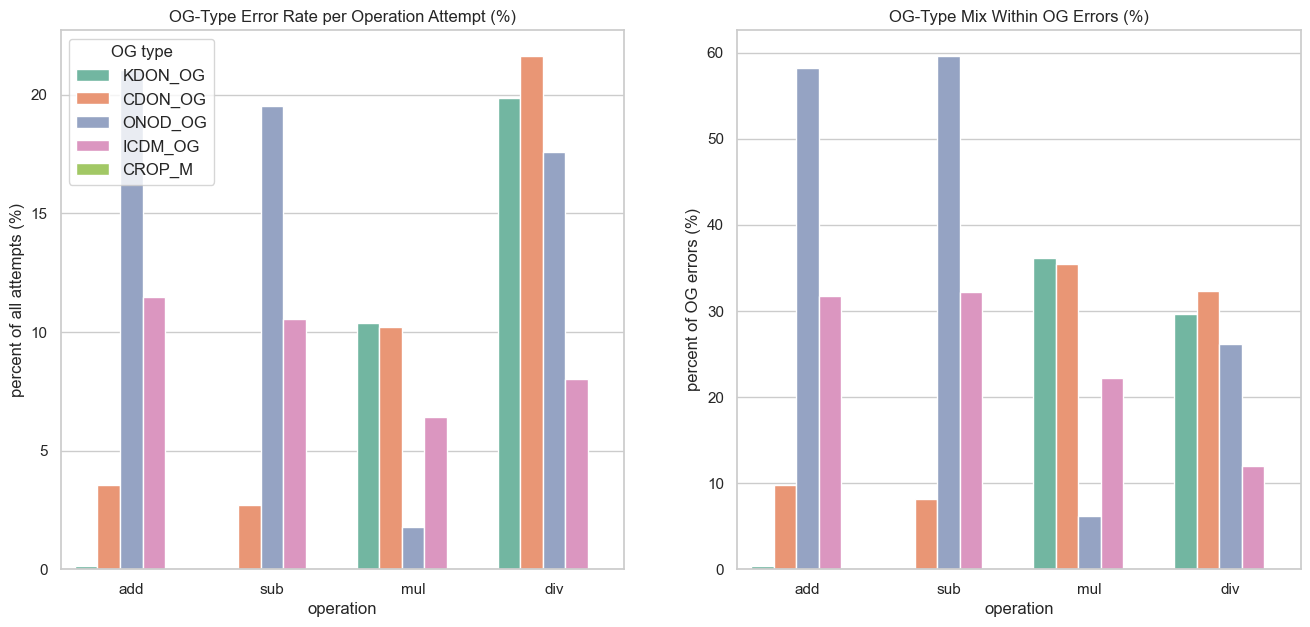

In [80]:
plt.rcParams.update({'font.size': 512})

ops = ['add', 'sub', 'mul', 'div']
og_codes = ['KDON_OG', 'CDON_OG', 'ONOD_OG', 'ICDM_OG', 'CROP_M']  # strict OG

og_err = verification_annot[
    verification_annot['error_flag'] & verification_annot['is_overgeneralized']
].copy()

# counts: operation x OG type
og_counts = (
    og_err.pivot_table(
        index='operation_norm',
        columns='strategy_code',
        values='subjid',
        aggfunc='count',
        fill_value=0,
    )
    .reindex(index=ops, columns=og_codes, fill_value=0)
)

# 1) OG-type error rate per operation attempt (%)
op_totals = verification_annot.groupby('operation_norm').size().reindex(ops)
og_rate_pct = (og_counts.div(op_totals, axis=0) * 100).fillna(0.0)

# 2) OG-type composition within each operation (%)
og_share_pct = (og_counts.div(og_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0.0)

# long format for seaborn
rate_long = og_rate_pct.reset_index().melt(
    id_vars='operation_norm', var_name='og_type', value_name='rate_pct'
)
share_long = og_share_pct.reset_index().melt(
    id_vars='operation_norm', var_name='og_type', value_name='share_pct'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

sns.barplot(
    data=rate_long, x='operation_norm', y='rate_pct', hue='og_type',
    ax=axes[0], palette='Set2'
)
axes[0].set_title('OG-Type Error Rate per Operation Attempt (%)')
axes[0].set_xlabel('operation')
axes[0].set_ylabel('percent of all attempts (%)')
axes[0].legend(title='OG type', fontsize=12)

sns.barplot(
    data=share_long, x='operation_norm', y='share_pct', hue='og_type',
    ax=axes[1], palette='Set2'
)
axes[1].set_title('OG-Type Mix Within OG Errors (%)')
axes[1].set_xlabel('operation')
axes[1].set_ylabel('percent of OG errors (%)')
axes[1].legend_.remove()

plt.tight_layout()
plt.show()


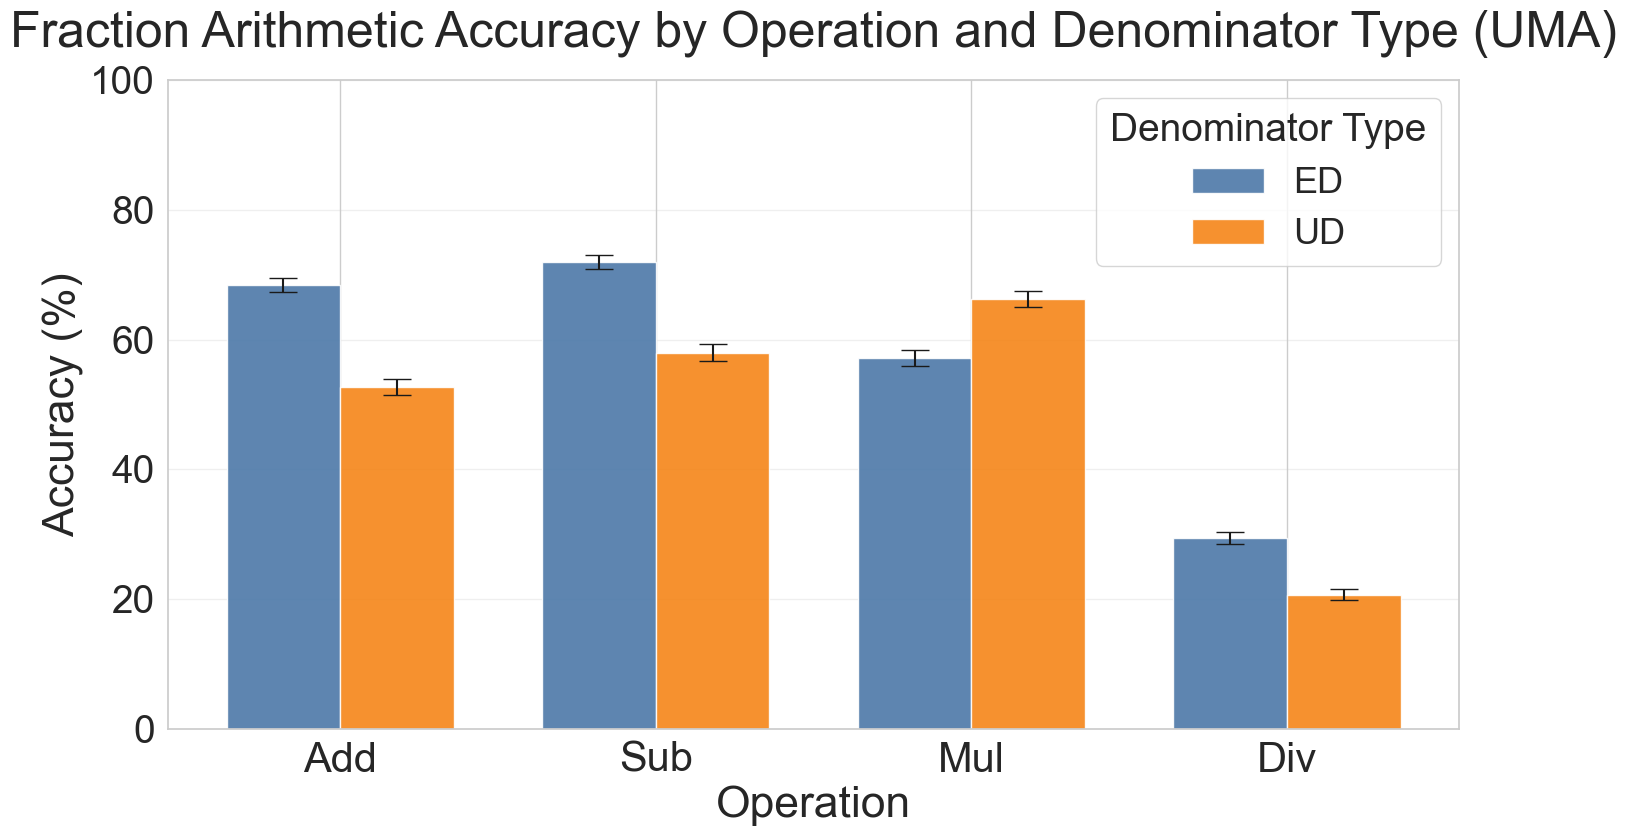

,operation_norm,denoms,mean_acc,se_acc,n
0,add,ED,0.684237,0.011161,996
1,add,UD,0.526606,0.012528,996
2,div,ED,0.294177,0.009677,996
3,div,UD,0.206827,0.008979,996
4,mul,ED,0.571285,0.012135,996
5,mul,UD,0.662651,0.012061,996
6,sub,ED,0.719378,0.010670,996
7,sub,UD,0.579819,0.012782,996


In [82]:
# Figure 5(B)-style: Accuracy by operation x denominator type (ED/UD), with SE bars

# Significantly increase all font sizes in matplotlib configuration, plot labels, tick labels, etc.
plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 36,
    'axes.labelsize': 32,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 28,
    'legend.title_fontsize': 30,
})

op_order = ['add', 'sub', 'mul', 'div']
op_labels = {'add': 'Add', 'sub': 'Sub', 'mul': 'Mul', 'div': 'Div'}
denom_order = ['ED', 'UD']

tmp = verification_annot.copy()
tmp['correct_flag'] = (~tmp['error_flag']).astype(int)

# per-student cell mean first (avoids pseudo-replication: each student contributes equally)
student_cell = (
    tmp.groupby(['subjid', 'operation_norm', 'denoms'], as_index=False)['correct_flag']
       .mean()
)

stats = (
    student_cell.groupby(['operation_norm', 'denoms'])['correct_flag']
    .agg(
        mean_acc='mean',
        se_acc=lambda x: x.std(ddof=1) / np.sqrt(len(x)),
        n='size',
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 9))
x = np.arange(len(op_order))
width = 0.36
colors = {'ED': '#4C78A8', 'UD': '#F58518'}

for i, d in enumerate(denom_order):
    s = (
        stats[stats['denoms'] == d]
        .set_index('operation_norm')
        .reindex(op_order)
    )
    xpos = x + (i - 0.5) * width
    bars = ax.bar(
        xpos,
        s['mean_acc'].values * 100,
        width=width,
        yerr=s['se_acc'].values * 100,
        capsize=10,
        color=colors[d],
        alpha=0.9,
        label=d,
    )

ax.set_xticks(x)
ax.set_xticklabels([op_labels[o] for o in op_order], fontsize=30)
ax.set_ylabel('Accuracy (%)', fontsize=32)
ax.set_xlabel('Operation', fontsize=32)
ax.set_title('Fraction Arithmetic Accuracy by Operation and Denominator Type (UMA)', fontsize=36, pad=24)
ax.set_ylim(0, 100)
ax.legend(title='Denominator Type', fontsize=26, title_fontsize=28)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

display(stats.sort_values(['operation_norm', 'denoms']))


## 4) Per-subjid error-type analysis (verification, incorrect trials)

In [66]:
all_subj = pd.Index(sorted(verification_annot['subjid'].unique()), name='subjid')

n_errors = verif_errors.groupby('subjid').size().reindex(all_subj, fill_value=0).rename('n_errors')

raw_counts = (
    verif_errors.pivot_table(
        index='subjid', columns='strategy_code', values='prob', aggfunc='count', fill_value=0
    )
    .reindex(all_subj, fill_value=0)
    .reindex(columns=STRATEGY_CODES, fill_value=0)
)

raw_props = raw_counts.div(raw_counts.sum(axis=1).replace(0, np.nan), axis=0)

family_counts = (
    verif_errors.pivot_table(
        index='subjid', columns='strategy_family', values='prob', aggfunc='count', fill_value=0
    )
    .reindex(all_subj, fill_value=0)
    .reindex(columns=['AS', 'M', 'D'], fill_value=0)
)
family_props = family_counts.div(family_counts.sum(axis=1).replace(0, np.nan), axis=0)

overgen_rate = verif_errors.groupby('subjid')['is_overgeneralized'].mean().reindex(all_subj)
dominant_error_type = raw_props.idxmax(axis=1)
dominant_error_type = dominant_error_type.where(n_errors > 0, np.nan)

per_subjid_summary = pd.DataFrame({
    'n_errors': n_errors,
    'overgeneralized_error_rate': overgen_rate,
    'dominant_error_type': dominant_error_type,
}).join(raw_props.add_prefix('raw_prop_')).join(family_props.add_prefix('family_prop_'))

row_sums = raw_props.loc[n_errors > 0].sum(axis=1)
assert np.allclose(row_sums.values, 1.0), (
    'Per-student raw proportions must sum to 1 for students with >=1 error.'
)

print('Per-subjid summary sample:')
display(per_subjid_summary.head(10))


Per-subjid summary sample:


,n_errors,overgeneralized_error_rate,dominant_error_type,raw_prop_KDON_AS,raw_prop_KDON_OG,raw_prop_CDON_AS,raw_prop_CDON_OG,raw_prop_ONOD_M,raw_prop_ONOD_OG,raw_prop_CROP_M,raw_prop_ICDM_D,raw_prop_ICDM_OG,family_prop_AS,family_prop_M,family_prop_D
subjid,,,,,,,,,,,,,,,
0,12,0.666667,ONOD_OG,0.0,0.166667,0.166667,0.083333,0.000000,0.416667,0.083333,0.083333,0.000000,0.416667,0.500000,0.083333
1,14,0.714286,ICDM_OG,0.0,0.071429,0.071429,0.142857,0.000000,0.214286,0.071429,0.142857,0.285714,0.285714,0.285714,0.428571
2,15,0.733333,ICDM_OG,0.0,0.133333,0.066667,0.200000,0.133333,0.133333,0.000000,0.066667,0.266667,0.400000,0.266667,0.333333
3,10,0.600000,CDON_OG,0.0,0.100000,0.100000,0.300000,0.000000,0.000000,0.300000,0.000000,0.200000,0.500000,0.300000,0.200000
4,10,0.800000,ICDM_OG,0.0,0.100000,0.100000,0.200000,0.100000,0.200000,0.000000,0.000000,0.300000,0.400000,0.300000,0.300000
5,13,0.769231,ONOD_OG,0.0,0.153846,0.076923,0.076923,0.153846,0.384615,0.000000,0.000000,0.153846,0.307692,0.538462,0.153846
6,14,0.714286,ICDM_OG,0.0,0.000000,0.071429,0.000000,0.071429,0.285714,0.071429,0.071429,0.428571,0.071429,0.428571,0.500000
7,13,0.692308,ICDM_OG,0.0,0.076923,0.230769,0.000000,0.000000,0.230769,0.000000,0.076923,0.384615,0.307692,0.230769,0.461538
8,11,0.727273,KDON_OG,0.0,0.181818,0.181818,0.181818,0.000000,0.181818,0.090909,0.000000,0.181818,0.545455,0.272727,0.181818


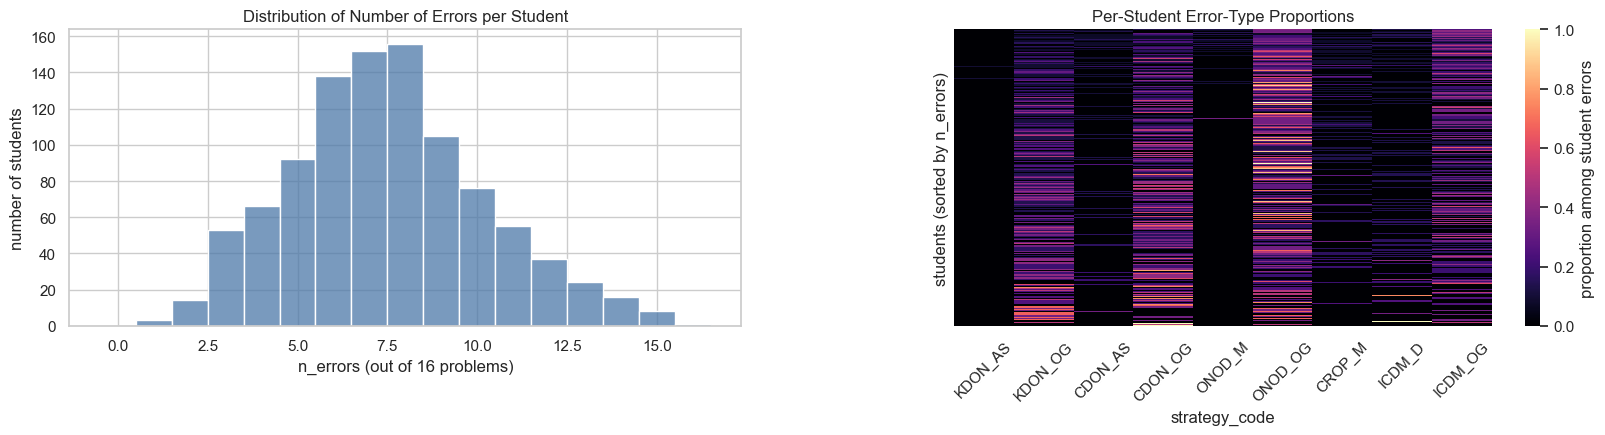

In [67]:
plt.rcParams.update({'font.size': 128})
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

bins = np.arange(per_subjid_summary['n_errors'].max() + 2) - 0.5
sns.histplot(per_subjid_summary['n_errors'], bins=bins, ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribution of Number of Errors per Student')
axes[0].set_xlabel('n_errors (out of 16 problems)')
axes[0].set_ylabel('number of students')

ordered_subj = per_subjid_summary.sort_values('n_errors', ascending=False).index
heat_data = raw_props.reindex(ordered_subj).fillna(0.0).reindex(columns=STRATEGY_CODES)

sns.heatmap(
    heat_data,
    ax=axes[1],
    cmap='magma',
    vmin=0,
    vmax=1,
    xticklabels=True,
    yticklabels=False,
    cbar_kws={'label': 'proportion among student errors'},
)
axes[1].set_title('Per-Student Error-Type Proportions')
axes[1].set_xlabel('strategy_code')
axes[1].set_ylabel('students (sorted by n_errors)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 5) Student correlation heatmap (full 996 x 996)

Pearson correlation on binary verification error profiles (`error_flag` by problem).


In [42]:
profile_df = build_student_error_profile(verification_annot)
corr_df = compute_student_corr(profile_df, method='pearson')

n_students = verification_annot['subjid'].nunique()
assert corr_df.shape == (n_students, n_students), f'Unexpected corr shape: {corr_df.shape}'
assert corr_df.index.equals(corr_df.columns), 'Correlation index/columns mismatch.'
assert np.allclose(np.diag(corr_df.values), 1.0), 'Correlation diagonal should be 1.'
assert np.allclose(corr_df.values, corr_df.values.T), 'Correlation matrix must be symmetric.'

print('profile_df shape (students x problems):', profile_df.shape)
print('corr_df shape:', corr_df.shape)

# try:
#     Z = linkage(profile_df.values, method='average', metric='euclidean')
#     order = leaves_list(Z)
#     ordered_subjid = profile_df.index[order]
# except Exception as exc:
#     print(f'Clustering failed ({exc}); using subjid order.')
ordered_subjid = profile_df.index

corr_ordered = corr_df.loc[ordered_subjid, ordered_subjid]


profile_df shape (students x problems): (996, 16)
corr_df shape: (996, 996)


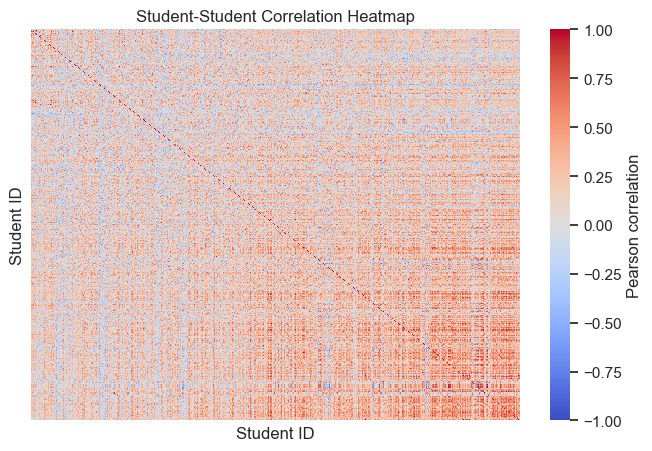

In [43]:
plt.rcParams.update({'font.size': 256})
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_ordered,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Pearson correlation'},
)
plt.title('Student-Student Correlation Heatmap')
plt.xlabel('Student ID')
plt.ylabel('Student ID')
plt.tight_layout()
plt.show()


/var/folders/41/2xrnw50s1cg695ql9qbf9y0h0000gn/T/ipykernel_81563/1789516274.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


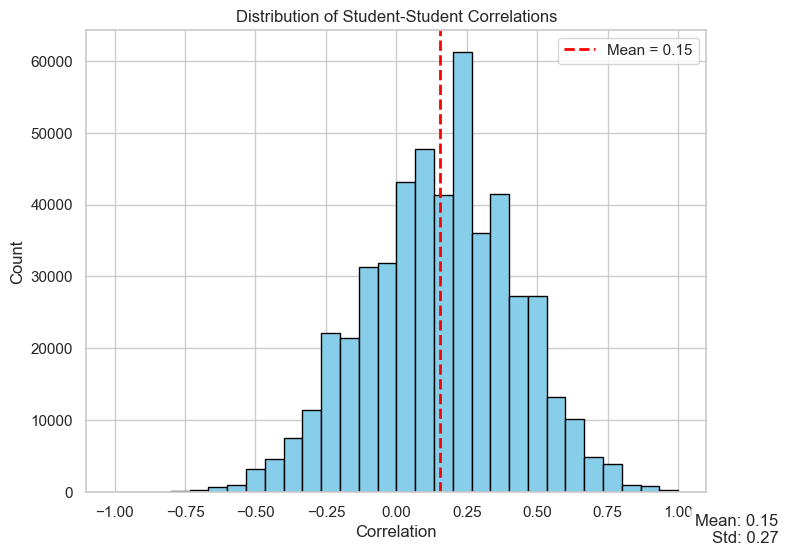

In [44]:
# Extract the upper triangular values (excluding diagonal) from corr_ordered
arr = corr_ordered.values
tri_i, tri_j = np.triu_indices_from(arr, k=1)
vals = arr[tri_i, tri_j]
valid = np.isfinite(vals)
vals = vals[valid]
# Now `vals` is a flat array of all unique student-student correlations (no duplicates, no diagonal, finite only)
# Compute mean and std
val_mean = np.mean(vals)
val_std = np.std(vals)
plt.figure(figsize=(8, 6))
n, bins, patches = plt.hist(vals, bins=30, color='skyblue', edgecolor='black')
plt.axvline(val_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {val_mean:.2f}')
plt.title('Distribution of Student-Student Correlations')
plt.xlabel('Correlation')
plt.ylabel('Count')
plt.legend()
# Add caption with mean and std as a text box in the figure
caption = f"Mean: {val_mean:.2f}\nStd: {val_std:.2f}"
plt.gcf().text(
    0.99, 0.02, caption, fontsize=12,
    ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [45]:
corr_ordered

subjid,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,94,95,96,99,100,101,102,103,...,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999
subjid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.218218,0.447214,-0.149071,-0.149071,0.092450,0.218218,-0.277350,-0.077850,-0.509175,0.092450,0.092450,0.447214,-0.072739,0.233550,-0.149071,-0.077850,-0.149071,-0.333333,0.072739,-0.149071,0.233550,-3.333333e-01,-0.389249,3.333333e-01,0.092450,0.218218,-3.333333e-01,0.000000,0.666667,-0.333333,0.072739,-4.625929e-17,0.072739,-0.218218,-0.077850,-0.277350,6.666667e-01,0.149071,-0.288675,-0.218218,-3.204938e-17,-1.017704e-16,0.218218,0.149071,0.218218,0.072739,0.0,-0.277350,5.551115e-17,-1.202742e-16,-0.447214,0.233550,2.886751e-01,1.850372e-17,-0.149071,-0.077850,-0.447214,0.218218,0.072739,0.149071,2.886751e-01,-0.149071,0.462250,-0.077850,0.333333,-0.077850,-3.204938e-17,-0.149071,-0.389249,0.092450,2.886751e-01,-0.218218,0.447214,0.462250,0.218218,0.218218,0.149071,-0.149071,-0.077850,1.850372e-17,-0.077850,0.218218,0.092450,0.149071,0.092450,1.850372e-17,3.333333e-01,-1.202742e-16,-0.447214,-0.077850,1.850372e-17,0.233550,-0.277350,-1.017704e-16,0.092450,-0.149071,-0.077850,-0.447214,0.149071,...,0.389249,2.886751e-01,-0.072739,-0.149071,-0.149071,0.389249,0.447214,0.149071,0.000000,7.401487e-17,0.072739,0.000000,0.218218,0.000000,0.149071,0.149071,0.000000,1.602469e-17,-1.602469e-17,-0.149071,0.072739,0.000000,-0.149071,-0.072739,-0.149071,-0.072739,-0.333333,-0.149071,-0.233550,0.077850,0.333333,-0.072739,0.149071,-0.363696,0.000000,-0.363696,0.218218,-0.363696,0.000000,-0.218218,-0.544949,2.775558e-17,2.775558e-17,0.218218,-0.149071,-0.218218,-0.233550,0.218218,-0.666667,-0.149071,-0.462250,-0.072739,0.218218,7.401487e-17,-0.462250,0.218218,-0.149071,-0.333333,-0.333333,0.218218,0.218218,-0.149071,-0.233550,-0.544949,-0.149071,-0.333333,-0.544949,-0.333333,-3.700743e-17,-0.333333,-0.233550,-0.218218,-0.072739,-0.333333,-0.149071,-0.233550,-0.072739,-0.233550,-0.666667,-0.092450,-0.447214,-0.149071,-0.149071,-0.462250,-0.462250,0.077850,-0.092450,-0.149071,-0.233550,-0.462250,-0.462250,0.218218,0.149071,-0.233550,-0.462250,-0.092450,-0.462250,-0.218218,-0.544949,-0.333333
1,0.218218,1.000000,0.683130,0.487950,0.487950,0.786796,-0.142857,-0.181568,-0.254824,0.047619,0.302614,0.302614,0.683130,-0.428571,-0.254824,0.683130,0.560612,0.292770,-0.218218,0.047619,0.683130,0.560612,2.182179e-01,0.152894,2.182179e-01,0.302614,0.428571,2.182179e-01,0.000000,-0.218218,0.218218,0.428571,-2.182179e-01,0.428571,0.428571,0.152894,0.302614,6.546537e-01,0.487950,0.377964,0.428571,3.779645e-01,6.546537e-01,0.428571,0.487950,1.000000,0.428571,0.0,0.302614,2.182179e-01,2.182179e-01,0.097590,0.152894,-2.098124e-17,2.182179e-01,0.683130,0.152894,0.097590,-0.142857,0.428571,-0.292770,3.779645e-01,0.097590,-0.181568,-0.254824,-0.218218,0.560612,0.000000e+00,0.292770,-0.254824,0.302614,3.779645e-01,-0.333333,0.487950,0.302614,0.428571,0.428571,-0.292770,-0.292770,0.152894,2.182179e-01,0.152894,-0.142857,0.302614,-0.292770,0.786796,2.182179e-01,2.182179e-01,2.182179e-01,0.097590,-0.254824,-2.182179e-01,0.152894,-0.181568,6.546537e-01,0.302614,0.683130,0.560612,0.097590,0.097590,...,0.254824,3.779645e-01,-0.047619,0.097590,0.292770,0.254824

In [46]:
arr = corr_df.values
tri_i, tri_j = np.triu_indices_from(arr, k=1)
vals = arr[tri_i, tri_j]
valid = np.isfinite(vals)
vals = vals[valid]

print('Off-diagonal correlation diagnostics:')
print(f'  min    : {vals.min():.4f}')
print(f'  median : {np.median(vals):.4f}')
print(f'  max    : {vals.max():.4f}')

pair_df = pd.DataFrame({
    'subjid_a': corr_df.index.to_numpy()[tri_i][valid],
    'subjid_b': corr_df.columns.to_numpy()[tri_j][valid],
    'corr': vals,
})

print('Top 10 most similar student pairs:')
display(pair_df.nlargest(10, 'corr').reset_index(drop=True))

print('Top 10 most dissimilar student pairs:')
display(pair_df.nsmallest(10, 'corr').reset_index(drop=True))


Off-diagonal correlation diagnostics:
  min    : -1.0000
  median : 0.1601
  max    : 1.0000
Top 10 most similar student pairs:


,subjid_a,subjid_b,corr
0,1,45,1.0
1,2,12,1.0
2,5,85,1.0
3,6,166,1.0
4,10,70,1.0
5,10,155,1.0
6,10,190,1.0
7,10,231,1.0
8,11,25,1.0
9,15,20,1.0


Top 10 most dissimilar student pairs:


,subjid_a,subjid_b,corr
0,63,660,-1.000000
1,64,702,-1.000000
2,103,274,-1.000000
3,82,871,-1.000000
4,82,945,-1.000000
5,82,971,-1.000000
6,212,336,-0.881917
7,205,627,-0.878310
8,612,960,-0.878310
9,723,960,-0.878310
